In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import torch
from torch.utils.data import DataLoader
from omegaconf import OmegaConf
import numpy as np

import what_where as ww

In [8]:
cfg = ww.utils.load_config("config_vcs_flexible")
figures_dir = ww.utils.get_figures_dir(cfg)
cfg.train.instance = 3

cfg.seed = 30
ww.utils.set_random_seed(cfg.seed)

cfg.dataset.meta_info = True

CONV_LAYER = "conv2" # which layer to visualize for the activations

ww.utils.pretty_print_cfg(cfg)

dataset:
  name: vcs
  large_img_size: 64
  target:
    size: 16
    centered: false
  distractors:
    size: 16
    n_min: 2
    n_max: 8
  min_distance: 10
  noise:
    min: 0.0
    max: 0.2
  what:
    size: 10
  where:
    size: 10
    sigma: 1.0
  mask_img: false
  mask_distractors:
    n_min: 10
    n_max: 15
  disk: false
  meta_info: true
  train_n: 60000
  valid_n: 10000
model:
  cnn:
    conv_channels:
    - 64
    - 128
    - 256
    kernel_sizes:
    - 5
    - 3
    - 3
    strides:
    - 2
    - 2
    - 2
    pre_training:
      train_weights: false
      load_weights: true
      checkpoint_dir: pretrained
    normalization:
      active: true
      pool_sizes:
      - 5
      - 5
      - 5
      sigma_spatial: 2.0
      sigma: 1.0
      alpha: 0.2
  rnn:
    hidden_size: 256
    n_layers: 3
    init_mlp_hidden_size: 64
    normalization:
      active: true
      sigma: 1.0
      alpha: 0.2
  gain:
    min: 0.0
    max: 2.0
    sensitivity: 1.0
    mlp_hidden: 256
    what

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# loading the latest checkpoint
checkpoint_path = ww.utils.get_checkpoint_path(cfg)
print("checkpoint file: ", checkpoint_path)
# checkpoint_path = get_best_checkpoint_from_cfg(cfg)
if checkpoint_path is None:
    raise ValueError("No checkpoint found for config")
checkpoint = torch.load(checkpoint_path, weights_only=False)

# loading the config from the checkpoint
checkpoint_cfg = OmegaConf.create(checkpoint["config"])
checkpoint_cfg.train.energy.st_sample_ratio = 1.0

# model = ww.model.Model(checkpoint_cfg)
model = ww.model.Model(cfg)

valid_dataset = ww.utils.get_datasets(cfg)["valid"]
dataloader = DataLoader(valid_dataset, batch_size=1, shuffle=True)

# loading model weights
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

n_passes = checkpoint_cfg.model.n_passes

epoch = checkpoint["epoch"]
noise_anneal = ww.utils.get_noise_anneal(checkpoint_cfg, epoch)


dataiter = iter(dataloader)
images, labels, meta_info = next(dataiter)
images = images.to(device)

# Run inference for all three energy costs
all_results = {}
for energy_name, energy_info in dict(cfg.plotting.flexible_inference_energy_levels).items():
    log_energy_cost = torch.tensor(energy_info["log_energy_cost"]).reshape(1, 1).to(device)
    
    predictions_what = []
    predictions_where = []
    activations = []
    pass_energies_ap = []
    pass_energies_st = []
    pass_energies_norm = []

    with torch.no_grad():
        out_full = model(images, log_energy_cost, n_passes, noise_anneal=noise_anneal)

    print(f"\n{energy_name}: {energy_info['log_energy_cost']}")
    print(out_full[0]["gain"]["combined"])

    for t in range(n_passes):
        predicted_what = torch.softmax(out_full[t]["prediction"]["what"], dim=1)
        n = int(np.sqrt(out_full[t]["prediction"]["where"].size(1)))
        predicted_where = torch.softmax(out_full[t]["prediction"]["where"], dim=1).view(
            -1, n, n
        )
        predictions_what.append(predicted_what)
        predictions_where.append(predicted_where)

        activations.append(out_full[t]["activations"])

        # pass energy
        energy_use = ww.utils.get_energy_use(cfg, out_full, t, device)
        pass_energies_ap.append(energy_use["ap"][0].item())
        pass_energies_st.append(energy_use["st"][0].item())
        pass_energies_norm.append(energy_use["norm"][0].item())
    
    all_results[energy_name] = {
        'predictions_what': predictions_what,
        'predictions_where': predictions_where,
        'activations': activations,
        'out_full': out_full,
        'pass_energies_ap': pass_energies_ap,
        'pass_energies_st': pass_energies_st,
        'log_energy_value': energy_info["log_energy_cost"]
    }


checkpoint dir:  /home/eivinas/dev/how-attention-saves-energy-in-vision/checkpoints/vcs/journal_flexible/ean_full/instance3
checkpoint:  /home/eivinas/dev/how-attention-saves-energy-in-vision/checkpoints/vcs/journal_flexible/ean_full/instance3/checkpoint_200.pth 

checkpoint file:  /home/eivinas/dev/how-attention-saves-energy-in-vision/checkpoints/vcs/journal_flexible/ean_full/instance3/checkpoint_200.pth

low: -12.0
{'conv1': tensor([[[[1.4146, 1.4090, 1.3977,  ..., 1.4129, 1.4126, 1.4125],
          [1.4146, 1.3811, 1.3115,  ..., 1.3218, 1.3225, 1.3228],
          [1.4146, 1.3236, 1.1195,  ..., 1.1177, 1.1206, 1.1221],
          ...,
          [1.4146, 1.3133, 1.0826,  ..., 1.0850, 1.0633, 1.0524],
          [1.4146, 1.3142, 1.0856,  ..., 1.0462, 1.0348, 1.0291],
          [1.4146, 1.3146, 1.0871,  ..., 1.0263, 1.0203, 1.0172]],

         [[0.8618, 0.8584, 0.8515,  ..., 0.8607, 0.8606, 0.8605],
          [0.8618, 0.8414, 0.7990,  ..., 0.8053, 0.8057, 0.8059],
          [0.8618, 0.806

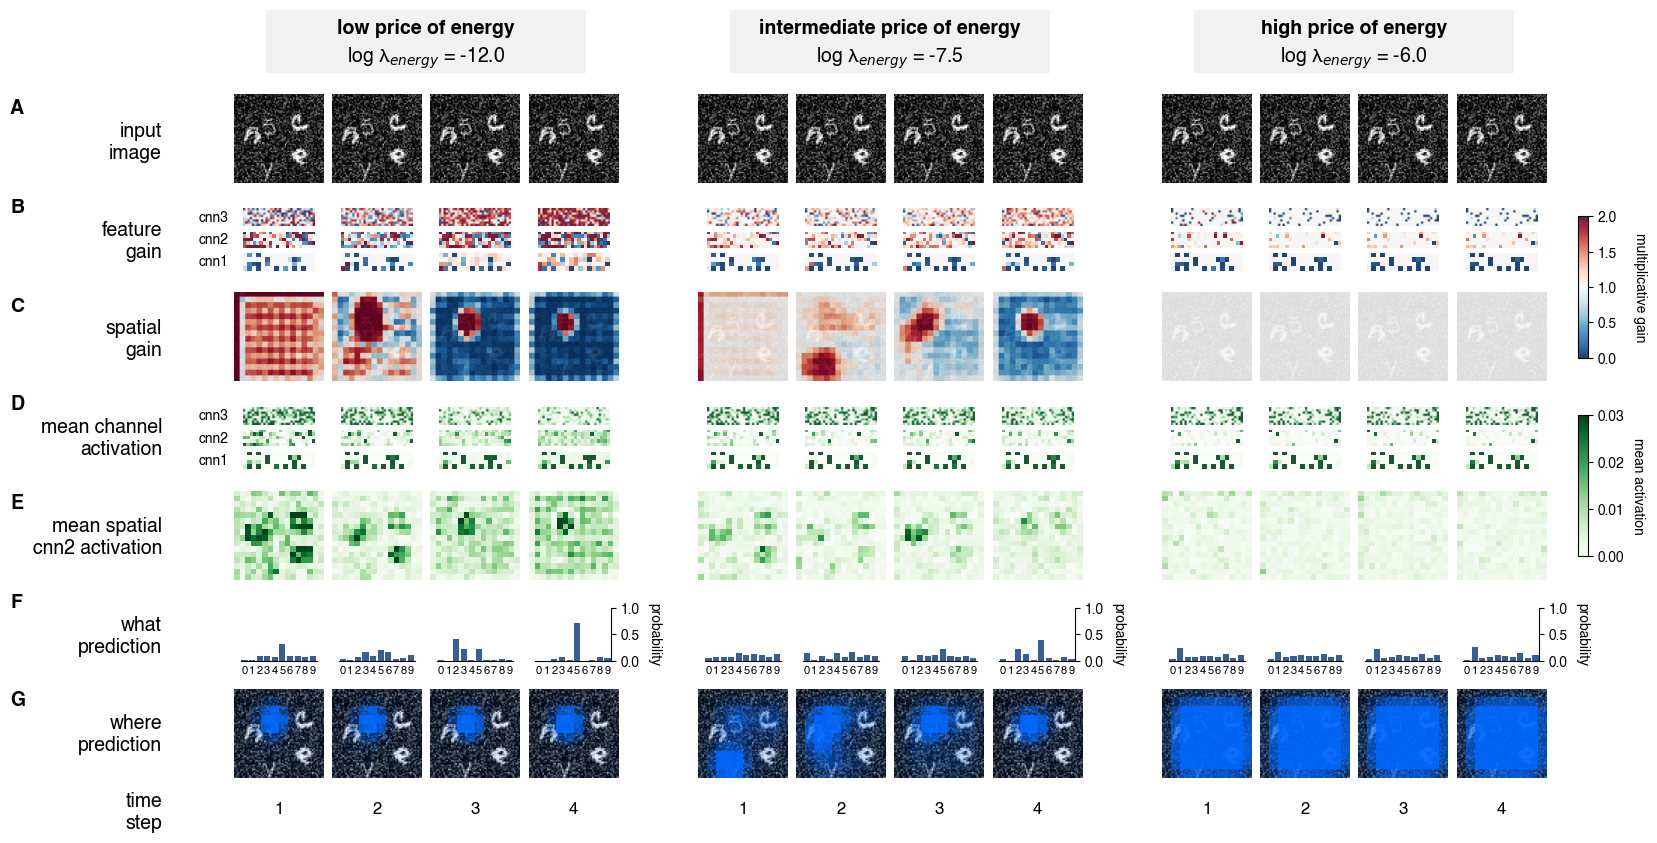

In [10]:
from matplotlib import gridspec
from matplotlib.patches import FancyBboxPatch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
plt.rcParams["font.family"] = "Helvetica"

# Layout parameters
VMAX_ACTIVATION = 0.03
CNN_FONTSIZE = 10
HEIGHT_RATIOS = [0.1, 1, 1, 1, 1, 1, 1, 1, 0.5]
CONV_INNER_WIDTH = 0.8
CONV_INNER_HEIGHT = 0.25
PRED_INNER_WIDTH = 0.85
PRED_INNER_HEIGHT = 0.8
conv_layer_names = dict(cfg.plotting.conv_layer_names)


def plot_conv_layers(ax, layer_data, conv_layer_names, t, panel_idx, cmap, vmin, vmax):
    """Plot stacked conv layer visualizations."""
    for j, (layer_name, data) in enumerate(layer_data.items()):
        # Create square representation
        n_rows = int(np.sqrt(len(data))/2)
        n_cols = int(np.sqrt(len(data))*2)
        data_square = np.zeros((n_rows, n_cols))
        data_square.flat[:len(data)] = data
        
        conv_left = (1 - CONV_INNER_WIDTH) / 2
        conv_bottom = j * CONV_INNER_HEIGHT + 0.1
        inner_ax = ax.inset_axes([conv_left, conv_bottom, CONV_INNER_WIDTH, CONV_INNER_HEIGHT])
        
        inner_ax.imshow(data_square, cmap=cmap, alpha=0.9, vmin=vmin, vmax=vmax)
        inner_ax.axis('off')
        
        # Add layer label (only for first timestep and first panel)
        if t == 0 and panel_idx == 0:
            inner_ax.text(-0.2, 0.5, conv_layer_names[layer_name], va='center', ha='right',
                        fontsize=CNN_FONTSIZE, transform=inner_ax.transAxes)
    
    ax.set_aspect("equal")
    ax.axis('off')

# Create three-panel figure
fig = plt.figure(figsize=(16, 9))




# Calculate panel layout positions
fig_left_margin = 0.02
row_label_width = 0.10
gap_after_labels = 0.04
gap_between_panels = 0.05
n_panels = 3

total_width = 1.0 - 2 * fig_left_margin
remaining_width = total_width - row_label_width - gap_after_labels
panel_width = (remaining_width - (n_panels - 1) * gap_between_panels) / n_panels

label_panel_left = fig_left_margin
panel_positions = [(fig_left_margin + row_label_width + gap_after_labels + i * (panel_width + gap_between_panels), panel_width) 
                   for i in range(n_panels)]

# Create row label panel
row_labels = ['', 'input\nimage', 'feature\ngain', 'spatial\ngain',
              'mean channel\nactivation', f'mean spatial\n{conv_layer_names[CONV_LAYER]} activation',
              'what\nprediction', 'where\nprediction', 'time\nstep']

label_gs = gridspec.GridSpec(9, 1, figure=fig, height_ratios=HEIGHT_RATIOS,
                              left=label_panel_left, right=label_panel_left + row_label_width,
                              top=0.92, bottom=0.08)

# letters = ['', 'a', 'b', 'c', 'd', 'e', 'f', 'g', '']
letters = ['', 'A', 'B', 'C', 'D', 'E', 'F', 'G', '']

for i in range(9):
    ax_label = fig.add_subplot(label_gs[i, 0])
    if i > 0:  # Skip empty title row
        ax_label.text(0.95, 0.5, row_labels[i], va='center', ha='right',
                      fontsize=14, fontweight="normal", transform=ax_label.transAxes)
        ax_label.text(0.0, 0.9, letters[i], va='center', ha='left', fontsize=14, fontweight="bold", transform=ax_label.transAxes)
    ax_label.axis('off')


# Create energy panels
# for panel_idx, (energy_key, energy_label) in enumerate(zip(energy_keys, energy_labels)):
for panel_idx, (energy_key, energy_info) in enumerate(dict(cfg.plotting.flexible_inference_energy_levels).items()):
    results = all_results[energy_key]
    log_energy_value = energy_info["log_energy_cost"]

    left, width = panel_positions[panel_idx]
    
    # Create GridSpec for this panel
    panel_gs = gridspec.GridSpec(9, n_passes, figure=fig, height_ratios=HEIGHT_RATIOS,
                                  width_ratios=[1] * n_passes, hspace=0.05, wspace=0.1,
                                  left=left, right=left+width, top=0.92, bottom=0.08)
    
    # Create subplot axes
    panel_axs = np.empty((9, n_passes), dtype=object)
    for i in range(9):
        for j in range(n_passes):
            panel_axs[i, j] = fig.add_subplot(panel_gs[i, j])
    
    # Hide title row axes and add centered titles
    for j in range(n_passes):
        panel_axs[0, j].axis('off')
    
    panel_center_x = left + width / 2
    fig.text(panel_center_x, 0.985, energy_info["label"], fontsize=14, fontweight="bold",
            va='top', ha='center', transform=fig.transFigure)
    fig.text(panel_center_x, 0.955, f"log λ$_{{energy}}$ = {energy_info['log_energy_cost']}",
            fontsize=14, va='top', ha='center', transform=fig.transFigure)
    
    width = 0.18
    height = 0.05
    box = FancyBboxPatch((panel_center_x - width/2, 0.96 - height/2), width, height,
                    boxstyle="square,pad=0.01",
                    transform=fig.transFigure,
                    facecolor='lightgray', alpha=0.3, edgecolor='none',
                    clip_on=False, zorder=-1)
    fig.add_artist(box)
    
    img_size = images[0].shape[-1]
    
    # Fill in the subplots for each timestep
    for t in range(n_passes):
        # Row 1: Input image
        panel_axs[1, t].imshow(images[0].cpu().numpy().squeeze(), cmap="gray")
        panel_axs[1, t].axis('off')
        
        # Row 2: Feature gain
        if cfg.model.gain.what.active:
            gain_data = {}
            for layer_name, gain in results['out_full'][t]["gain"]["what"].items():
                gain_vector = gain[0].cpu().numpy()
                gain_vector = ww.utils.scale_gain(cfg, gain_vector)
                gain_data[layer_name] = gain_vector
            
            plot_conv_layers(panel_axs[2, t], gain_data, conv_layer_names, t, panel_idx, 
                           "RdBu_r", cfg.model.gain.min, cfg.model.gain.max)
        else:
            panel_axs[2, t].axis('off')
        
        # Row 3: Spatial gain
        if checkpoint_cfg.model.gain.where.active:
            heatmap = results['out_full'][t]["gain"]["where"][0].cpu().numpy()
            scale_factor = img_size // heatmap.shape[0]
            heatmap_resized = np.repeat(np.repeat(heatmap, scale_factor, axis=0), scale_factor, axis=1)
            heatmap_resized = ww.utils.scale_gain(cfg, heatmap_resized)
            
            panel_axs[3, t].imshow(images[0].cpu().numpy().squeeze(), cmap="gray")
            im_spatial = panel_axs[3, t].imshow(heatmap_resized, cmap="RdBu_r", alpha=0.9,
                                   vmin=cfg.model.gain.min, vmax=cfg.model.gain.max)
            
            # Add colorbar for gain rows (only for last timestep and last panel)
            if t == n_passes - 1 and panel_idx == 2:
                # Get position of both rows to center the colorbar between them
                pos2 = panel_axs[2, t].get_position()
                pos3 = panel_axs[3, t].get_position()
                # Calculate center position and height spanning both rows
                center_y = (pos2.y0 + pos3.y1) / 2
                total_height = pos2.y1 - pos3.y0
                cbar_height = total_height * 0.75  # 75% of total height
                cbar_y = center_y - cbar_height / 2
                cbar_ax = fig.add_axes([pos3.x1 + 0.02, cbar_y, 0.006, cbar_height])
                cbar = fig.colorbar(im_spatial, cax=cbar_ax)
                cbar.ax.tick_params(labelsize=10)
                cbar.set_label('multiplicative gain', rotation=270, labelpad=22, fontsize=10)
        
        panel_axs[3, t].axis('off')
        
        # Row 4: Mean channel activation
        activation_data = {}
        conv_layers = [layer for layer in results['activations'][t].keys() if layer in conv_layer_names]
        for layer_name in conv_layers:
            feature_map = results['activations'][t][layer_name][0].cpu().numpy()
            if len(feature_map.shape) == 3:
                activation_vector = feature_map.mean(axis=(1, 2))
            elif len(feature_map.shape) == 2:
                activation_vector = np.array([feature_map.mean()])
            else:
                activation_vector = feature_map
            activation_data[layer_name] = activation_vector
        
        plot_conv_layers(panel_axs[4, t], activation_data, conv_layer_names, t, panel_idx,
                        "Greens", 0, VMAX_ACTIVATION)
        
        # Row 5: Mean spatial activation
        feature_map = results['activations'][t][CONV_LAYER][0].cpu().numpy()
        if len(feature_map.shape) == 3:
            heatmap = feature_map.mean(axis=0)
        elif len(feature_map.shape) == 2:
            heatmap = feature_map
        else:
            size = int(np.sqrt(len(feature_map)))
            heatmap = feature_map[:size*size].reshape(size, size)
        
        im_spatial_act = panel_axs[5, t].imshow(heatmap, cmap="Greens", alpha=1.0, vmin=0, vmax=VMAX_ACTIVATION)
        panel_axs[5, t].axis('off')
        panel_axs[5, t].set_aspect("equal")
        
        # Add colorbar for activation rows (only for last timestep and last panel)
        if t == n_passes - 1 and panel_idx == 2:
            # Get position of both rows to center the colorbar between them
            pos4 = panel_axs[4, t].get_position()
            pos5 = panel_axs[5, t].get_position()
            # Calculate center position and height spanning both rows
            center_y = (pos4.y0 + pos5.y1) / 2
            total_height = pos4.y1 - pos5.y0
            cbar_height = total_height * 0.75  # 75% of total height
            cbar_y = center_y - cbar_height / 2
            cbar_ax = fig.add_axes([pos5.x1 + 0.02, cbar_y, 0.006, cbar_height])
            cbar = fig.colorbar(im_spatial_act, cax=cbar_ax)
            cbar.ax.tick_params(labelsize=10)
            cbar.set_label('mean activation', rotation=270, labelpad=15, fontsize=10)
        
        # Row 6: What prediction
        pred_left = (1 - PRED_INNER_WIDTH) / 2
        pred_bottom = (1 - PRED_INNER_HEIGHT) / 2
        inner_ax = panel_axs[6, t].inset_axes([pred_left, pred_bottom, PRED_INNER_WIDTH, PRED_INNER_HEIGHT])
        
        inner_ax.bar(range(10), results['predictions_what'][t][0].cpu().numpy(),
                     color=cfg.plotting.prediction_color, width=0.8)
        inner_ax.set_ylim(0, 1)
        inner_ax.set_xlim(-0.5, 9.5)
        inner_ax.set_xticks(range(10))
        inner_ax.set_xticklabels(range(10), fontsize=8)
        inner_ax.tick_params(axis='x', length=0)
        inner_ax.set_aspect(7.0)
        inner_ax.spines['top'].set_visible(False)
        inner_ax.spines['left'].set_visible(False)
        
        if t == n_passes - 1:
            inner_ax.set_yticks([0, 0.5, 1.0])
            inner_ax.set_yticklabels([0.0, 0.5, 1.0], fontsize=10)
            inner_ax.yaxis.tick_right()
            inner_ax.yaxis.set_label_position("right")
            inner_ax.set_ylabel("probability", rotation=270, labelpad=15, fontsize=10)
            inner_ax.spines['right'].set_visible(True)
        else:
            inner_ax.set_yticks([])
            inner_ax.spines['right'].set_visible(False)
        
        panel_axs[6, t].axis('off')
        
        # Row 7: Where prediction
        heatmap = results['predictions_where'][t][0].cpu().numpy()
        scale_factor = img_size // heatmap.shape[0]
        heatmap_resized = np.repeat(np.repeat(heatmap, scale_factor, axis=0), scale_factor, axis=1)
        
        panel_axs[7, t].imshow(images[0].cpu().numpy().squeeze(), cmap="gray")
        color_rgba = mcolors.to_rgba("#0068ff")
        alpha_values = np.linspace(0.1, 1.8, 256)
        color_list = [(color_rgba[0], color_rgba[1], color_rgba[2], alpha) for alpha in alpha_values]
        custom_cmap = mcolors.LinearSegmentedColormap.from_list('custom', color_list)
        panel_axs[7, t].imshow(heatmap_resized, cmap=custom_cmap, alpha=0.95)
        panel_axs[7, t].axis('off')
        
        # Row 8: Time labels
        panel_axs[8, t].text(0.5, 0.5, str(t+1), fontsize=12, va='center', ha='center', transform=panel_axs[8, t].transAxes)
        panel_axs[8, t].axis('off')

   
fig.savefig(figures_dir / "fig3_model_inference.png", dpi=500, bbox_inches='tight')
fig.savefig(figures_dir / "fig3_model_inference.pdf", dpi=500, bbox_inches='tight')
